# Problem Overview

### How to accurately identify and reduce the most significant risk factors of heart disease in a large, diverse population, using tools like machine learning to enhance prevention and early detection


### Why is it important to solve?
#### High prevalence of heart disease and its major risk factors among the U.S. population, and the need for improved identification and prevention strategies

# Getting Started

In [115]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, make_scorer, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import json

import seaborn as sns
import matplotlib.pyplot as plt


colors = ['skyblue', 'salmon', 'lightgreen', 'lightcoral', 'lightblue', 'lightyellow', 'lightpink', 'lightgray']


In [116]:

df = pd.read_csv('./data/heart_2022_with_nans.csv')

df.sample(20)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
308733,Oregon,Female,Good,NaN,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.68,65.77,23.40,No,No,Yes,NaN,"Yes, received tetanus shot, but not Tdap",No,No
116833,Iowa,Male,Good,30.0,0.0,Within past year (anytime less than 12 months ...,Yes,6.0,1 to 5,No,...,1.91,117.93,32.50,No,Yes,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
29649,California,Female,Good,0.0,3.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10757,Arizona,Female,NaN,21.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,NaN,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
291131,Ohio,Female,Fair,20.0,30.0,Within past year (anytime less than 12 months ...,Yes,8.0,1 to 5,No,...,1.63,68.95,26.09,No,Yes,No,No,"No, did not receive any tetanus shot in the pa...",No,No
10446,Arizona,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,10.0,None of them,No,...,1.52,68.04,29.29,No,No,No,Yes,"Yes, received tetanus shot but not sure what type",No,No
372197,Vermont,Male,Good,2.0,2.0,Within past 2 years (1 year but less than 2 ye...,Yes,9.0,1 to 5,No,...,1.65,58.97,21.63,Yes,No,No,No,"Yes, received tetanus shot but not sure what type",No,No
163658,Maryland,Female,Excellent,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.75,65.77,21.41,Yes,Yes,No,NaN,"Yes, received tetanus shot but not sure what type",No,No
107210,Indiana,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,None of them,No,...,1.57,53.07,21.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117209,Iowa,Male,Excellent,0.0,0.0,Within past 2 years (1 year but less than 2 ye...,Yes,7.0,1 to 5,No,...,1.83,147.42,44.08,Yes,No,No,No,"Yes, received tetanus shot but not sure what type",No,No


In [117]:
df.shape

(445132, 40)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

## EDA
### 1. Understand the Problem & Dataset
#### 1.1 Define Business Objective
#### 1.2 Understand target variable
1. Identify feature types
    1. Numerical: continuous, discrete
    2. Categorical: nominal, ordinal
    3. Text / Dates / Images
### 2. Data Collection and Overview
1. Check duplicates
2. Check Nulls
3. Check outliers
#### 3. Data Cleaning
1. Handle Missing Values
2. Handle Duplicates
3. Handle Outliers
    1. IQR method / Z-score
    2. Box plots
#### 4. Univariate Analysis
1. For Numeric features check distribution
2. For Categorical features check Frequency count
#### 5. [Bivariate Analysis](#bivariate-analysis)
1. Numerical v/s Target  
    1. Box plot
2. Categorical v/s Target  
    1. Count plot
#### 6. Multivariate Analysis
1. Correlation heatmaps for numeric features
2. Detect multicollinearity
#### 7. Encoding Categorical Features
1. Label Encoding for Ordinal categories
2. One-Hot Encoding for Nominal categories 
#### 8. Feature Scaling 
1. StandardScaler
#### 9. Feature Selection
1. Identify most relevant features 
    1. Is PCA good option?
#### 10. Feature Engineering
1. Create new meaningful features 
#### 11. Train-Test split 


###################################################################################################################################################

#### 1.2 Understand target variable
1. Identify feature types
    1. Numerical: continuous, discrete
    2. Categorical: nominal, ordinal
    3. Text / Dates / Images

<span style="color: green; font-weight: bold; font-size:20px">Target variable is "HadHeartAttack"</span>


<span style="color: green; font-weight: bold; font-size:16px">List if Numeric columns</span>


In [119]:
numeric_columns = df.select_dtypes(exclude='object').columns
print(f"Numerical columns: {numeric_columns.to_list()} ")
print("-" * 120)

Numerical columns: ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI'] 
------------------------------------------------------------------------------------------------------------------------


<span style="color: green; font-weight: bold; font-size:16px">List if Non-Numeric columns</span>

In [120]:
# List columns with type as Object
object_columns = df.select_dtypes(include='object').columns.sort_values()
print("Object columns:", list(object_columns))
print("-" * 40)

# For loop to get unique values of each object column and print the results
# for col in object_columns.sort_values():
#     # print(f"Unique values in column '{col}':")
#     # print(df[col].unique())
#     print(df[col].value_counts(dropna=False, ascending=True))
#     print("-" * 40)


Object columns: ['AgeCategory', 'AlcoholDrinkers', 'BlindOrVisionDifficulty', 'ChestScan', 'CovidPos', 'DeafOrHardOfHearing', 'DifficultyConcentrating', 'DifficultyDressingBathing', 'DifficultyErrands', 'DifficultyWalking', 'ECigaretteUsage', 'FluVaxLast12', 'GeneralHealth', 'HIVTesting', 'HadAngina', 'HadArthritis', 'HadAsthma', 'HadCOPD', 'HadDepressiveDisorder', 'HadDiabetes', 'HadHeartAttack', 'HadKidneyDisease', 'HadSkinCancer', 'HadStroke', 'HighRiskLastYear', 'LastCheckupTime', 'PhysicalActivities', 'PneumoVaxEver', 'RaceEthnicityCategory', 'RemovedTeeth', 'Sex', 'SmokerStatus', 'State', 'TetanusLast10Tdap']
----------------------------------------


<span style="color: green; font-weight: bold; font-size:16px">Identified Boolean columns</span>


In [121]:
boolean_columns = ["AlcoholDrinkers", "BlindOrVisionDifficulty", "ChestScan", "DeafOrHardOfHearing", "DifficultyConcentrating","DifficultyDressingBathing", "DifficultyErrands","DifficultyWalking", "FluVaxLast12", "HIVTesting", "HadAngina", "HadArthritis", "HadAsthma", "HadCOPD", "HadDepressiveDisorder", "HadKidneyDisease", "HadSkinCancer", "HadStroke", "HighRiskLastYear", "PhysicalActivities", "PneumoVaxEver"]

for col in boolean_columns:
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

AlcoholDrinkers
Yes    210891
No     187667
NaN     46574
Name: count, dtype: int64
----------------------------------------
BlindOrVisionDifficulty
No     399910
Yes     23658
NaN     21564
Name: count, dtype: int64
----------------------------------------
ChestScan
No     223221
Yes    165865
NaN     56046
Name: count, dtype: int64
----------------------------------------
DeafOrHardOfHearing
No     385539
Yes     38946
NaN     20647
Name: count, dtype: int64
----------------------------------------
DifficultyConcentrating
No     370792
Yes     50100
NaN     24240
Name: count, dtype: int64
----------------------------------------
DifficultyDressingBathing
No     404404
NaN     23915
Yes     16813
Name: count, dtype: int64
----------------------------------------
DifficultyErrands
No     387029
Yes     32447
NaN     25656
Name: count, dtype: int64
----------------------------------------
DifficultyWalking
No     353039
Yes     68081
NaN     24012
Name: count, dtype: int64
-------------

### 2. Data Collection and Overview
1. Check duplicates
2. Check Nulls
3. Check outliers

<span style="color: green; font-weight: bold; font-size:16px">Check column wise % of Null value records</span>


In [122]:
# Percentage of null values in each column
nan_percent = df.isna().mean().mul(100).to_frame('NaN %')

nan_percent.sort_values(by='NaN %', ascending=False)


,NaN %
TetanusLast10Tdap,18.537423
PneumoVaxEver,17.307226
HIVTesting,14.855593
ChestScan,12.590872
CovidPos,11.404258
HighRiskLastYear,11.372582
BMI,10.964388
FluVaxLast12,10.585849
AlcoholDrinkers,10.462964
WeightInKilograms,9.452926



<span style="color:red"># Note:Following columns may be dropped because it has more than 15% of the rows with No Data</span> 


In [123]:
# Query nan_percent to give records which are more than 15%
high_nan = nan_percent[nan_percent['NaN %'] > 15].sort_values(by='NaN %', ascending=False)
print(high_nan)


                       NaN %
TetanusLast10Tdap  18.537423
PneumoVaxEver      17.307226


<span style="color: green; font-weight: bold; font-size:16px">Finding number of rows with all NULL values and number of duplicates</span>

In [124]:
# Number of rows with all NULL values

num_rows_all_null = df.isnull().all(axis=1).sum()
print(f"Number of rows with all columns NULL: {num_rows_all_null}")
print("-" * 120)

# Find duplicate records in the dataframe
duplicate_rows = df[df.duplicated(keep=False)]
print(f"Number of duplicate records: {len(duplicate_rows)}")
if not duplicate_rows.empty:
    print("Sample duplicate records:")
    display(duplicate_rows.head())


Number of rows with all columns NULL: 0
------------------------------------------------------------------------------------------------------------------------
Number of duplicate records: 302
Sample duplicate records:


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
4712,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7310,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10696,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
11503,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
26789,California,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<span style="color: green; font-weight: bold; font-size:16px">Check for outliers in numeric data columns using IQR method</span>

Outlier summary for numeric columns:


,Column,Num Outliers,Percent Outliers,Max Outlier,Min Outlier
3,PhysicalHealthDays,72269,16.64,30.00,8.00
2,MentalHealthDays,60389,13.85,30.00,13.00
0,BMI,12339,3.11,99.64,12.02
5,WeightInKilograms,9643,2.39,292.57,22.68
4,SleepHours,7260,1.65,24.00,1.00
1,HeightInMeters,1556,0.37,2.41,0.91


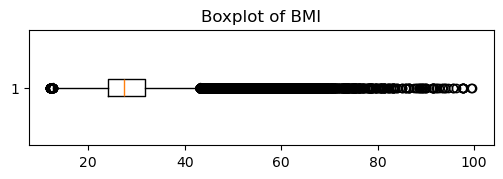

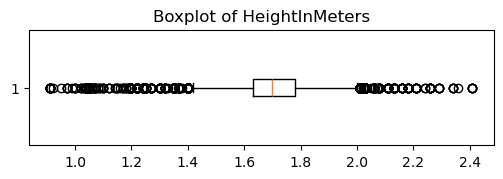

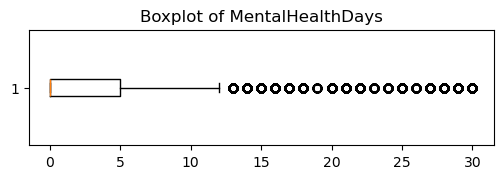

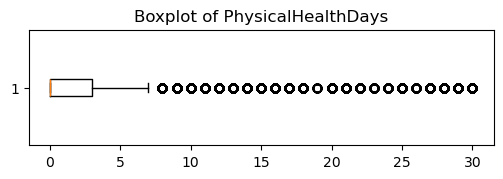

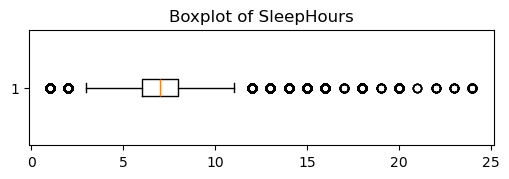

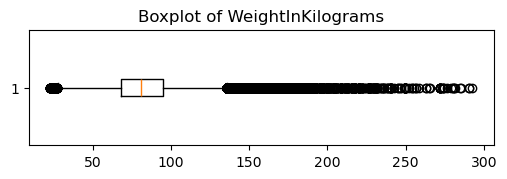

In [125]:
# Check for outliers in numeric data columns using IQR method

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.sort_values()

# print(numeric_columns)

outlier_summary = pd.DataFrame(columns=["Column", "Num Outliers", "Percent Outliers", "Max Outlier", "Min Outlier"])

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    num_outliers = outliers.count()
    percent_outliers = (num_outliers / df[col].count()) * 100 if df[col].count() > 0 else 0
    max_outlier = outliers.max()
    min_outlier = outliers.min()        
    outlier_summary.loc[len(outlier_summary)] = [col, num_outliers, round(percent_outliers, 2), max_outlier, min_outlier]

print("Outlier summary for numeric columns:")
display(outlier_summary.sort_values(by="Percent Outliers", ascending=False))

# Visualize outliers for each numeric column
import matplotlib.pyplot as plt
for col in numeric_columns:
    plt.figure(figsize=(6, 1.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()


<span style="color: green; font-weight: bold; font-size:16px">Check for outliers in numeric data columns using Z-score method</span>

In [126]:
from scipy.stats import zscore

# Calculate Z-scores for numeric columns
z_scores = df[numeric_columns].dropna().apply(zscore)

# print(z_scores)

# Set a threshold for Z-score to identify outliers (commonly 3 or -3)
z_threshold = 3

z_outlier_summary = pd.DataFrame(columns=["Column", "Num Outliers", "Percent Outliers", "Max Z", "Min Z"])

for col in numeric_columns:
    # Find outliers based on Z-score
    outliers = z_scores[(z_scores[col].abs() > z_threshold)][col]
    num_outliers = outliers.count()
    percent_outliers = (num_outliers / df[col].count()) * 100 if df[col].count() > 0 else 0
    max_z = df[col].max()
    min_z = df[col].min()
    z_outlier_summary.loc[len(z_outlier_summary)] = [col, num_outliers, round(percent_outliers, 2), round(max_z, 2), round(min_z, 2)]

print("Outlier summary for numeric columns using Z-Score:")
display(z_outlier_summary.sort_values(by="Percent Outliers", ascending=False))


Outlier summary for numeric columns using Z-Score:


,Column,Num Outliers,Percent Outliers,Max Z,Min Z
2,MentalHealthDays,22929,5.26,30.00,0.00
4,SleepHours,5899,1.34,24.00,1.00
0,BMI,4806,1.21,99.64,12.02
5,WeightInKilograms,3960,0.98,292.57,22.68
1,HeightInMeters,824,0.20,2.41,0.91
3,PhysicalHealthDays,0,0.00,30.00,0.00


<span style="color: brown; font-weight: bold; font-size:20px">##After analyzing outlier results, I have decided not to remove All the outlier data because to be those outliers seems to be valid data. For example WeightInKg can be 292.57, but HeightInMeters of .91 meters (3 feet) seems to eb non realistic, same for SleepHours of 24 hours</span>

### Univariate analysis
<span style="color: green; font-weight: bold; font-size:16px">Plot histogram for all numeric columns except "HadHeartAttack"</span>

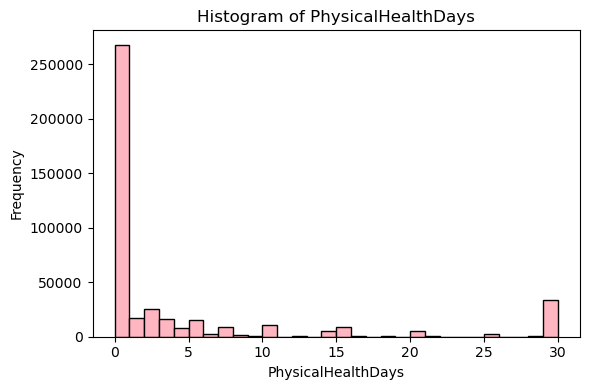

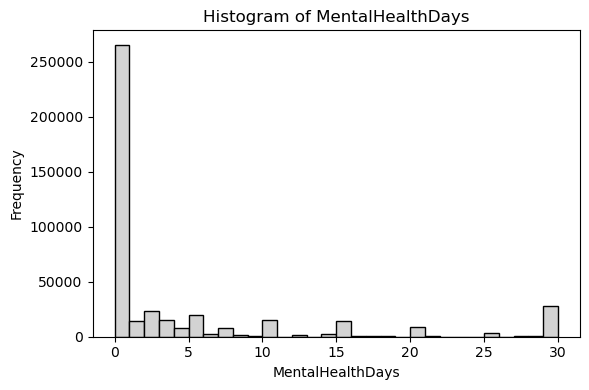

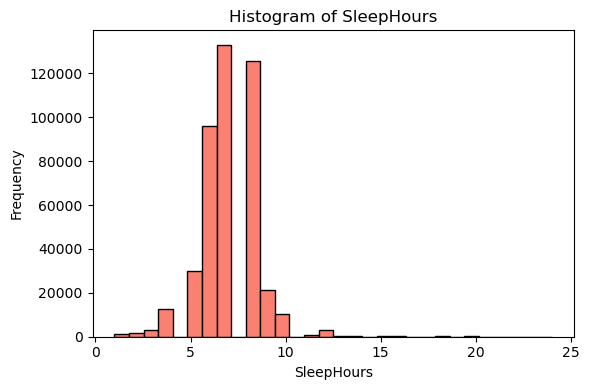

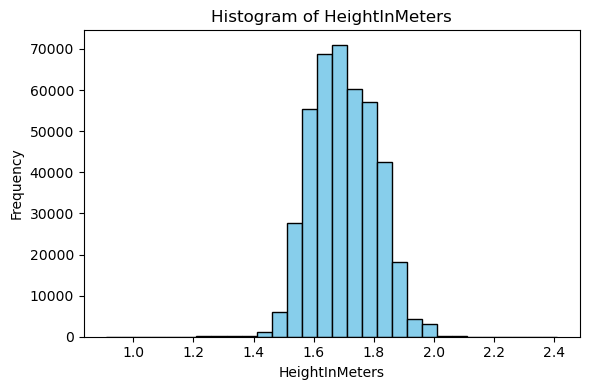

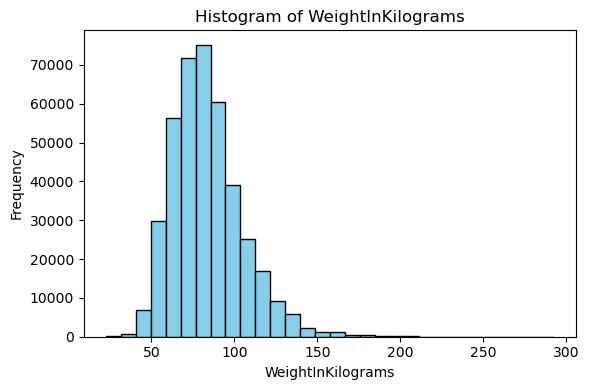

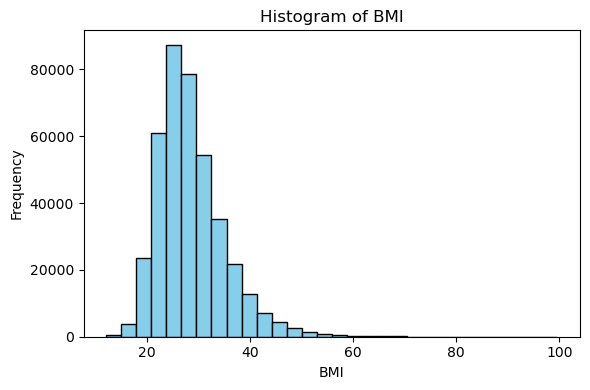

In [127]:
# Plot histogram for all numeric columns except "HadHeartAttack"
import random
import matplotlib.pyplot as plt

columns_to_plot = df.select_dtypes(exclude='object').columns

for col in columns_to_plot:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30, color=colors[random.randint(0, len(colors) - 1)], edgecolor='black')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")

    plt.tight_layout()
    plt.show()


#### 3. Data Cleaning
1. Handle Missing Values
2. Handle Duplicates
3. Handle Outliers

In [128]:
# Create a copy of the original dataframe
df_original = df.copy()

In [ ]:
# Keep this code commented and use it only if you want to revert back to original dataframe
# df = df_original.copy()

<span style="color: green; font-weight: bold; font-size:16px">Dropping duplicates</span>


In [129]:
# Remove duplicate records from df
print(f"Number of duplicate records before removing duplicates: {len(df)}")
df = df.drop_duplicates()
print(f"Number of duplicate records after removing duplicates: {len(df)}")


Number of duplicate records before removing duplicates: 445132
Number of duplicate records after removing duplicates: 444975


Dropping NULL data from target column __HadHeartAttack__

In [131]:
# Drop rows where HadHeartAttack is null

df = df.dropna(subset=['HadHeartAttack'])

print(df["HadHeartAttack"].value_counts(dropna=False))


HadHeartAttack
No     416807
Yes     25108
Name: count, dtype: int64


Transforming data for HadHeartAttach column to numeric value as 0 for No, and 1 for yes


In [132]:
print("Unique values in HadHeartAttack column:")
print(df['HadHeartAttack'].unique())
print("\nData type:", df['HadHeartAttack'].dtype)

# Map 'No' to 0 and 'Yes' to 1 in HadHeartAttack column
df['HadHeartAttack'] = df['HadHeartAttack'].map({'No': 0, 'Yes': 1})
print(df["HadHeartAttack"].value_counts(dropna=False))


Unique values in HadHeartAttack column:
['No' 'Yes']

Data type: object
HadHeartAttack
0    416807
1     25108
Name: count, dtype: int64


##### Handling Missing Values for Numeric columns

<span style="color: green; font-weight: bold; font-size:16px">PhysicalHealthDays and MentalHealthDays has highly skewed data, so imputing it using median value</span>



In [133]:
print(numeric_columns)

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

nan_percent = df[numeric_columns].isna().mean().mul(100).to_frame('NaN %')

nan_percent.sort_values(by='NaN %', ascending=False)


Index(['BMI', 'HeightInMeters', 'MentalHealthDays', 'PhysicalHealthDays',
       'SleepHours', 'WeightInKilograms'],
      dtype='object')


,NaN %
BMI,0.0
HeightInMeters,0.0
MentalHealthDays,0.0
PhysicalHealthDays,0.0
SleepHours,0.0
WeightInKilograms,0.0


##### Handling Missing Values for Categorical columns

In [134]:
# print(object_columns)
# print(boolean_columns)

# Print unique values of object columns that are not boolean columns
non_boolean_object_columns = [col for col in object_columns if col not in boolean_columns]

print(non_boolean_object_columns)

for col in non_boolean_object_columns:
    print(f"Unique values for column '{col}':")
    print(df[col].unique())
    print("-" * 100)



['AgeCategory', 'CovidPos', 'ECigaretteUsage', 'GeneralHealth', 'HadDiabetes', 'HadHeartAttack', 'LastCheckupTime', 'RaceEthnicityCategory', 'RemovedTeeth', 'Sex', 'SmokerStatus', 'State', 'TetanusLast10Tdap']
Unique values for column 'AgeCategory':
['Age 80 or older' 'Age 55 to 59' nan 'Age 40 to 44' 'Age 75 to 79'
 'Age 70 to 74' 'Age 65 to 69' 'Age 60 to 64' 'Age 50 to 54'
 'Age 45 to 49' 'Age 35 to 39' 'Age 25 to 29' 'Age 30 to 34'
 'Age 18 to 24']
----------------------------------------------------------------------------------------------------
Unique values for column 'CovidPos':
['No' 'Yes' nan
 'Tested positive using home test without a health professional']
----------------------------------------------------------------------------------------------------
Unique values for column 'ECigaretteUsage':
['Not at all (right now)' 'Never used e-cigarettes in my entire life' nan
 'Use them every day' 'Use them some days']
------------------------------------------------------------

__Creating Maps for categorical columns:__

'AgeCategory', 'AlcoholDrinkers', 'BlindOrVisionDifficulty',
'ChestScan', 'CovidPos', 'DeafOrHardOfHearing',
'DifficultyConcentrating', 'DifficultyDressingBathing',
'DifficultyErrands', 'DifficultyWalking', 'ECigaretteUsage',
'FluVaxLast12', 'GeneralHealth', 'HIVTesting', 'HadAngina',
'HadArthritis', 'HadAsthma', 'HadCOPD', 'HadDepressiveDisorder',
'HadDiabetes', 'HadHeartAttack', 'HadKidneyDisease', 'HadSkinCancer',
'HadStroke', 'HighRiskLastYear', 'LastCheckupTime',
'PhysicalActivities', 'PneumoVaxEver', 'RaceEthnicityCategory',
'RemovedTeeth', 'Sex', 'SmokerStatus', 'State', 'TetanusLast10Tdap'

<u>__AgeCategory__</u>

In [135]:

columnName = "AgeCategory"

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

df = df.dropna(subset=[columnName])
# df[columnName] = df[columnName].fillna('Unknown')

columns_map = {
    'Age 18 to 24': 1, 
    'Age 25 to 29': 2, 
    'Age 30 to 34': 3, 
    'Age 35 to 39': 4, 
    'Age 40 to 44': 5, 
    'Age 45 to 49': 6, 
    'Age 50 to 54': 7, 
    'Age 55 to 59': 8, 
    'Age 60 to 64': 9, 
    'Age 65 to 69': 10, 
    'Age 70 to 74': 11, 
    'Age 75 to 79': 12, 
    'Age 80 or older': 13
    }

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)
print(f"{columnName} Column exists: {columnName in df.columns}")




AgeCategory
NaN                 8802
Age 25 to 29       21901
Age 30 to 34       25687
Age 18 to 24       26792
Age 35 to 39       28371
Age 45 to 49       28392
Age 40 to 44       29778
Age 75 to 79       32231
Age 50 to 54       33436
Age 80 or older    35736
Age 55 to 59       36611
Age 70 to 74       43194
Age 60 to 64       44191
Age 65 to 69       46793
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack       0     1
AgeCategory                 
Age 18 to 24     26670   122
Age 25 to 29     21782   119
Age 30 to 34     25500   187
Age 35 to 39     28053   318
Age 40 to 44     29333   445
Age 45 to 49     27664   728
Age 50 to 54     32186  1250
Age 55 to 59     34651  1960
Age 60 to 64     41301  2890
Age 65 to 69     43093  3700
Age 70 to 74     38978  4216
Age 75 to 79     28442  3789
Age 80 or older  30712  5024
NaN               8442   360
-----------------------------------------------

/var/folders/2f/6_4hcwj934j6nmv5h4kjmt9m0000gn/T/ipykernel_29462/2651594908.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columnName] = df[columnName].map(columns_map)


CovidPos

['No' 'Yes' nan 'Tested positive using home test without a health professional']

In [136]:
columnName = "CovidPos"

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

# df = df.dropna(subset=[columnName])
df[columnName] = df[columnName].fillna('Unknown')

columns_map = {
    'No': 0,
    'Yes': 1,
    'Tested positive using home test without a health professional': 2,
    'Unknown': -1
    }

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)
print(f"{columnName} Column exists: {columnName in df.columns}")




CovidPos
Tested positive using home test without a health professional     13242
NaN                                                               47561
Yes                                                              108773
No                                                               263537
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack                                           0      1
CovidPos                                                         
No                                                  247345  16192
Tested positive using home test without a healt...   12850    392
Yes                                                 103270   5503
NaN                                                  44900   2661
----------------------------------------------------------------------------------------------------
CovidPos
 2     13242
-1     47561
 1    108773
 0    263537
Name: count, dtype

ECigaretteUsage

['Not at all (right now)' 'Never used e-cigarettes in my entire life' nan
 'Use them every day' 'Use them some days']

<span style="color: green; font-weight: bold; font-size:16px">Note: combining 'Not at all (right now)' and 'Never used e-cigarettes in my entire life' as 0</span>

In [26]:
columnName = "ECigaretteUsage"

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

df[columnName] = df[columnName].fillna('Unknown')

# combining 'Not at all (right now)' and 'Never used e-cigarettes in my entire life' as 0

columns_map = {
    'Not at all (right now)': 0,
    'Never used e-cigarettes in my entire life': 0,
    'Use them every day': 1,
    'Use them some days': 2,
    'Unknown': -1
}

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Optionally, drop the original column if you want to keep only the mapped version
# df = df.drop(columns=[columnName])

ECigaretteUsage
Use them every day                            10235
Use them some days                            11529
NaN                                           33101
Not at all (right now)                        73743
Never used e-cigarettes in my entire life    304505
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack                                  0      1
ECigaretteUsage                                         
Never used e-cigarettes in my entire life  286710  17795
Not at all (right now)                      69464   4279
Use them every day                           9916    319
Use them some days                          11077    452
NaN                                         31198   1903
----------------------------------------------------------------------------------------------------
ECigaretteUsage
 1     10235
 2     11529
-1     33101
 0    378248
Name: count, dtype: int64
---

GeneralHealth

['Very good' 'Excellent' 'Fair' 'Poor' 'Good' nan]

In [27]:
columnName = "GeneralHealth"

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

df = df.dropna(subset=[columnName])

# combining 'Not at all (right now)' and 'Never used e-cigarettes in my entire life' as 0

columns_map = {
    'Excellent': 5,
    'Very good': 4,
    'Good': 3,
    'Fair': 2,
    'Poor': 1,
}

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Optionally, drop the original column if you want to keep only the mapped version
# df = df.drop(columns=[columnName])

GeneralHealth
NaN            1030
Poor          19023
Fair          58523
Excellent     69906
Good         139596
Very good    145035
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack       0     1
GeneralHealth               
Excellent        68830  1076
Fair             51385  7138
Good            131429  8167
Poor             14906  4117
Very good       140896  4139
NaN                919   111
----------------------------------------------------------------------------------------------------
GeneralHealth
1     19023
2     58523
5     69906
3    139596
4    145035
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


/var/folders/2f/6_4hcwj934j6nmv5h4kjmt9m0000gn/T/ipykernel_29462/3029337914.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columnName] = df[columnName].map(columns_map)


HadDiabetes

['Yes' 'No' 'No, pre-diabetes or borderline diabetes' nan
 'Yes, but only during pregnancy (female)']

In [28]:
columnName = "HadDiabetes"

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

df = df.dropna(subset=[columnName])

columns_map = {
   'No': 0,
   'Yes': 1,
   'Yes, but only during pregnancy (female)': 2,
   'No, pre-diabetes or borderline diabetes': 3,
}

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Optionally, drop the original column if you want to keep only the mapped version
# df = df.drop(columns=[columnName])

HadDiabetes
NaN                                           735
Yes, but only during pregnancy (female)      3748
No, pre-diabetes or borderline diabetes     10050
Yes                                         59278
No                                         358272
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
HadHeartAttack                                0      1
HadDiabetes                                           
No                                       343093  15179
No, pre-diabetes or borderline diabetes    9276    774
Yes                                       50779   8499
Yes, but only during pregnancy (female)    3639    109
NaN                                         659     76
----------------------------------------------------------------------------------------------------
HadDiabetes
2      3748
3     10050
1     59278
0    358272
Name: count, dtype: int64
---------------------------------------

/var/folders/2f/6_4hcwj934j6nmv5h4kjmt9m0000gn/T/ipykernel_29462/2525015941.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columnName] = df[columnName].map(columns_map)


LastCheckupTime

['Within past year (anytime less than 12 months ago)' nan
 'Within past 2 years (1 year but less than 2 years ago)'
 'Within past 5 years (2 years but less than 5 years ago)'
 '5 or more years ago']

In [29]:
columnName = "LastCheckupTime"

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

# df = df.dropna(subset=[columnName])
df[columnName] = df[columnName].fillna('Unknown')


columns_map = {
   'Within past year (anytime less than 12 months ago)': 1,
   'Within past 2 years (1 year but less than 2 years ago)': 2,
   'Within past 5 years (2 years but less than 5 years ago)': 3,
   '5 or more years ago': 4,
   'Unknown': -1
}

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Optionally, drop the original column if you want to keep only the mapped version
# df = df.drop(columns=[columnName])  



HadHeartAttack                                           0      1
LastCheckupTime                                                  
5 or more years ago                                  18057    410
Within past 2 years (1 year but less than 2 yea...   39629   1118
Within past 5 years (2 years but less than 5 ye...   23712    509
Within past year (anytime less than 12 months ago)  318204  22216
NaN                                                   7185    308
----------------------------------------------------------------------------------------------------
LastCheckupTime
-1      7493
 4     18467
 3     24221
 2     40747
 1    340420
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


RaceEthnicityCategory

['White only, Non-Hispanic' 'Black only, Non-Hispanic'
 'Other race only, Non-Hispanic' 'Multiracial, Non-Hispanic' nan
 'Hispanic']

In [30]:
columnName = "RaceEthnicityCategory"

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

# df = df.dropna(subset=[columnName])
df[columnName] = df[columnName].fillna('Unknown')


# combining Other race only, Non-Hispanic' and 'unknown' as 3

columns_map = {
   'White only, Non-Hispanic': 1,   
   'Black only, Non-Hispanic': 2,
   'Other race only, Non-Hispanic': 3,
   'Multiracial, Non-Hispanic': 4,
   'Hispanic': 5,
   'Unknown': 3
}

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Optionally, drop the original column if you want to keep only the mapped version
# df = df.drop(columns=[columnName])  
print(f"{columnName} Column exists: {columnName in df.columns}")

print("*" * 100)


HadHeartAttack                      0      1
RaceEthnicityCategory                       
Black only, Non-Hispanic        32522   1644
Hispanic                        40182   1597
Multiracial, Non-Hispanic        8741    574
Other race only, Non-Hispanic   20853   1012
White only, Non-Hispanic       293674  18947
NaN                             10815    787
----------------------------------------------------------------------------------------------------
RaceEthnicityCategory
4      9315
3     33467
2     34166
5     41779
1    312621
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
RaceEthnicityCategory Column exists: True
****************************************************************************************************


RemovedTeeth

[nan 'None of them' '1 to 5' '6 or more, but not all' 'All']

In [31]:
columnName = "RemovedTeeth"

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

# df = df.dropna(subset=[columnName])
df[columnName] = df[columnName].fillna('Unknown')


columns_map = {
  'None of them': 0,
  '1 to 5': 1,
  '6 or more, but not all': 2,
  'All': 3,
  'Unknown': -1
}

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Optionally, drop the original column if you want to keep only the mapped version
# df = df.drop(columns=[columnName])  
print(f"{columnName} Column exists: {columnName in df.columns}")

print("*" * 100)

HadHeartAttack               0     1
RemovedTeeth                        
1 to 5                  118017  7560
6 or more, but not all   38947  5332
All                      20291  4278
None of them            220304  6413
NaN                       9228   978
----------------------------------------------------------------------------------------------------
RemovedTeeth
-1     10206
 3     24569
 2     44279
 1    125577
 0    226717
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
RemovedTeeth Column exists: True
****************************************************************************************************


SmokerStatus

['Never smoked' 'Current smoker - now smokes some days' 'Former smoker'
 nan 'Current smoker - now smokes every day']

In [32]:
columnName = "SmokerStatus"

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

# df = df.dropna(subset=[columnName])
df[columnName] = df[columnName].fillna('Unknown')

columns_map = {
  'Never smoked': 0,
  'Former smoker': 1,
  'Current smoker - now smokes some days': 2,
  'Current smoker - now smokes every day': 3,
  'Unknown': -1
}

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Optionally, drop the original column if you want to keep only the mapped version
# df = df.drop(columns=[columnName])  
print(f"{columnName} Column exists: {columnName in df.columns}")

print("*" * 100)

HadHeartAttack                              0     1
SmokerStatus                                       
Current smoker - now smokes every day   32001  3137
Current smoker - now smokes some days   12592   959
Former smoker                          101378  9574
Never smoked                           229980  9092
NaN                                     30836  1799
----------------------------------------------------------------------------------------------------
SmokerStatus
 2     13551
-1     32635
 3     35138
 1    110952
 0    239072
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
SmokerStatus Column exists: True
****************************************************************************************************


TetanusLast10Tdap

['Yes, received tetanus shot but not sure what type'
 'No, did not receive any tetanus shot in the past 10 years' nan
 'Yes, received Tdap' 'Yes, received tetanus shot, but not Tdap']

In [33]:
columnName = "TetanusLast10Tdap"

grouped = df.groupby([columnName, 'HadHeartAttack'], dropna=False)
print(grouped.size().unstack())
print("-" * 100)

# df = df.dropna(subset=[columnName])
df[columnName] = df[columnName].fillna('Unknown')

# combining 'Yes, received tetanus shot but not sure what type', 'Yes, received tetanus shot, but not Tdap' and 'Yes, received Tdap' as 1
# combining 'No, did not receive any tetanus shot in the past 10 years' as 0

columns_map = {
  'Yes, received tetanus shot but not sure what type': 1,
  'No, did not receive any tetanus shot in the past 10 years': 0,
  'Yes, received Tdap': 1,
  'Yes, received tetanus shot, but not Tdap': 1,
  'Unknown': -1
}

df[columnName] = df[columnName].map(columns_map)

print(df[columnName].value_counts(dropna=False, ascending=True))
print("-" * 100)

# Optionally, drop the original column if you want to keep only the mapped version
# df = df.drop(columns=[columnName])  
print(f"{columnName} Column exists: {columnName in df.columns}")

print("*" * 100)

HadHeartAttack                                           0     1
TetanusLast10Tdap                                               
No, did not receive any tetanus shot in the pas...  110699  7418
Yes, received Tdap                                   93972  3974
Yes, received tetanus shot but not sure what type   103488  7116
Yes, received tetanus shot, but not Tdap             25006  1787
NaN                                                  73622  4266
----------------------------------------------------------------------------------------------------
TetanusLast10Tdap
-1     77888
 0    118117
 1    235343
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
TetanusLast10Tdap Column exists: True
****************************************************************************************************


#### Null Handling for Boolean (Yes, No, NaN) columns

['AlcoholDrinkers', 'BlindOrVisionDifficulty', 'ChestScan', 'DeafOrHardOfHearing', 'DifficultyConcentrating', 'DifficultyDressingBathing', 'DifficultyErrands', 'DifficultyWalking', 'FluVaxLast12', 'HIVTesting', 'HadAngina', 'HadArthritis', 'HadAsthma', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadSkinCancer', 'HadStroke', 'HighRiskLastYear', 'PhysicalActivities', 'PneumoVaxEver']

In [34]:
print("*" * 100)
# print (boolean_columns)

for column in boolean_columns:
    df[column] = df[column].fillna('Unknown')
    df[column] = df[column].map({'Yes': 1, 'No': 0, 'Unknown': -1})
    print(df[column].value_counts(dropna=False, ascending=True))
    print("-" * 100)


****************************************************************************************************
AlcoholDrinkers
-1     43119
 0    181725
 1    206504
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
BlindOrVisionDifficulty
-1     19727
 1     22746
 0    388875
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
ChestScan
-1     52324
 1    161224
 0    217800
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
DeafOrHardOfHearing
-1     18862
 1     37606
 0    374880
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
DifficultyConcentrating
-1     22188
 1     48513
 0    360647
Name: count, dtype: int64
----------------------------------------------------------------------------

#### Data verification after Null Handling and Data transformation 

In [35]:
# Percentage of null values in each column
nan_percent = df.isna().mean().mul(100).to_frame('NaN %')

nan_percent.sort_values(by='NaN %', ascending=False)

,NaN %
State,0.0
Sex,0.0
DifficultyWalking,0.0
DifficultyDressingBathing,0.0
DifficultyErrands,0.0
SmokerStatus,0.0
ECigaretteUsage,0.0
ChestScan,0.0
RaceEthnicityCategory,0.0
AgeCategory,0.0


In [36]:
allColumns = df.columns.sort_values()

for column in allColumns:
    print(column)
    print(df[column].value_counts(dropna=False, ascending=True))
    print("-" * 100)



AgeCategory
AgeCategory
2     21822
3     25587
1     26668
4     28281
6     28289
5     29682
12    32088
7     33309
13    35489
8     36487
11    43031
9     44013
10    46602
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
AlcoholDrinkers
AlcoholDrinkers
-1     43119
 0    181725
 1    206504
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
BMI
BMI
48.63        1
31.76        1
65.80        1
40.22        1
43.67        1
         ...  
27.12     3013
24.41     3104
27.46     3218
26.63     4170
27.44    46464
Name: count, Length: 3959, dtype: int64
----------------------------------------------------------------------------------------------------
BlindOrVisionDifficulty
BlindOrVisionDifficulty
-1     19727
 1     22746
 0    388875
Name: count, dtype: int64
--------------------------------------------------------------------

#### Encoding Nominal Categorical Features


In [37]:
object_columns = df.select_dtypes(include='object').columns.tolist()
print("Object columns:", object_columns)

numeric_columns = df.select_dtypes(exclude=['object']).columns.tolist()
print("Numeric columns:", numeric_columns)


Object columns: ['State', 'Sex']
Numeric columns: ['GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']


<u>__1. Sex__</u>

In [137]:
# One-hot encode the 'Sex' column
sex_dummies = pd.get_dummies(df['Sex'], prefix='Sex')
df = pd.concat([df.drop('Sex', axis=1), sex_dummies], axis=1)

# Show the new columns created for 'Sex'
print("One-hot encoded columns for 'Sex':", sex_dummies.columns.tolist())

print("-" * 100)

One-hot encoded columns for 'Sex': ['Sex_Female', 'Sex_Male']
----------------------------------------------------------------------------------------------------


<u>__2. State__</u>

In [138]:
# One-hot encode the 'State' column
state_dummies = pd.get_dummies(df['State'], prefix='State')
df = pd.concat([df.drop('State', axis=1), state_dummies], axis=1)

# Show the new columns created for 'State'
print("One-hot encoded columns for 'State':", state_dummies.columns.tolist())
print("-" * 100)


One-hot encoded columns for 'State': ['State_Alabama', 'State_Alaska', 'State_Arizona', 'State_Arkansas', 'State_California', 'State_Colorado', 'State_Connecticut', 'State_Delaware', 'State_District of Columbia', 'State_Florida', 'State_Georgia', 'State_Guam', 'State_Hawaii', 'State_Idaho', 'State_Illinois', 'State_Indiana', 'State_Iowa', 'State_Kansas', 'State_Kentucky', 'State_Louisiana', 'State_Maine', 'State_Maryland', 'State_Massachusetts', 'State_Michigan', 'State_Minnesota', 'State_Mississippi', 'State_Missouri', 'State_Montana', 'State_Nebraska', 'State_Nevada', 'State_New Hampshire', 'State_New Jersey', 'State_New Mexico', 'State_New York', 'State_North Carolina', 'State_North Dakota', 'State_Ohio', 'State_Oklahoma', 'State_Oregon', 'State_Pennsylvania', 'State_Puerto Rico', 'State_Rhode Island', 'State_South Carolina', 'State_South Dakota', 'State_Tennessee', 'State_Texas', 'State_Utah', 'State_Vermont', 'State_Virgin Islands', 'State_Virginia', 'State_Washington', 'State_Wes

### Bivariate Analysis

In [42]:
print(numeric_columns)
print("-" * 100)
print(object_columns)


['GeneralHealth', 'PhysicalHealthDays', 'MentalHealthDays', 'LastCheckupTime', 'PhysicalActivities', 'SleepHours', 'RemovedTeeth', 'HadHeartAttack', 'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes', 'DeafOrHardOfHearing', 'BlindOrVisionDifficulty', 'DifficultyConcentrating', 'DifficultyWalking', 'DifficultyDressingBathing', 'DifficultyErrands', 'SmokerStatus', 'ECigaretteUsage', 'ChestScan', 'RaceEthnicityCategory', 'AgeCategory', 'HeightInMeters', 'WeightInKilograms', 'BMI', 'AlcoholDrinkers', 'HIVTesting', 'FluVaxLast12', 'PneumoVaxEver', 'TetanusLast10Tdap', 'HighRiskLastYear', 'CovidPos']
----------------------------------------------------------------------------------------------------
['State', 'Sex']


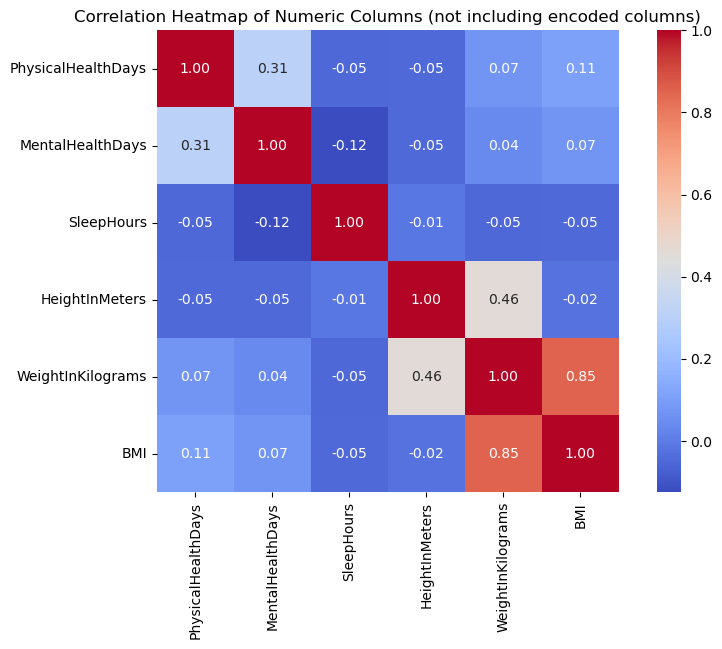

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter numeric_columns to exclude columns starting with 'State_'
# filtered_numeric_columns = [col for col in numeric_columns if not col.startswith('State_') and not col.startswith('Sex_')]
original_numeric_columns = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI'] 

# Compute the correlation matrix for the filtered numeric columns
corr_matrix = df[original_numeric_columns].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Columns (not including encoded columns)")
plt.show()



### Feature Selection


In [ ]:

# Calculate and print the variance of the numeric_columns
variances_before_scaling = df[numeric_columns].var()

scaled_data = StandardScaler().fit_transform(df[numeric_columns])
scaled_df = pd.DataFrame(scaled_data, columns=numeric_columns)
variances = scaled_df.var()
variances_comparison = pd.DataFrame({
    'Variance Before Scaling': variances_before_scaling,
    'Variance After Scaling': variances
})
print("Comparison of variances before and after scaling:")
print(variances_comparison)

# print(variances )

----------------------------------------------------------------------------------------------------
Comparison of variances before and after scaling:
                           Variance Before Scaling  Variance After Scaling
GeneralHealth                             1.103972                1.000002
PhysicalHealthDays                       73.713950                1.000002
MentalHealthDays                         69.109645                1.000002
LastCheckupTime                           0.683591                1.000002
PhysicalActivities                        0.187795                1.000002
SleepHours                                2.208616                1.000002
RemovedTeeth                              0.823746                1.000002
HadHeartAttack                            0.053698                1.000002
HadAngina                                 0.064684                1.000002
HadStroke                                 0.043541                1.000002
HadAsthma               

#### Train-Test Split

In [72]:
from sklearn.model_selection import train_test_split

# For classification, encode the target if it's not numeric
y = df[target_variable]

X = df.drop(columns=[target_variable])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (345078, 93) (345078,)
Test shape: (86270, 93) (86270,)


### A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [73]:
# The baseline is the accuracy we'd get by always predicting the most frequent class.
# Find the most frequent class in the training set
most_frequent_class = y_train.value_counts().idxmax()
print(f"Most frequent class: {most_frequent_class}")
baseline_accuracy = (y_test == most_frequent_class).mean()

print(f"Baseline accuracy (majority class '{most_frequent_class}'): {baseline_accuracy:.4f}")

Most frequent class: 0
Baseline accuracy (majority class '0'): 0.9431
